<a href="https://colab.research.google.com/github/adljna/Blu-SentimentAnalysis/blob/main/Week%204/BOW/4-BagOfWords-BluAppReview.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Week 4 - Bag of Words Blu App Review**
This notebook continues the review scraping process previously explained in [3-EDA-BluAppReview.ipynb](https://colab.research.google.com/drive/1eO5s0b2993cytZc84VHVzbcAqhvIboP8?usp=sharing)

# **(1) Setup and Import Libraries**
Install and import necessary Python libraries for data manipulation, text processing, vectorization, and visualization.

This section installs and imports essential Python libraries: `pandas` for data handling, `scikit-learn` for text vectorization, `numpy` for numerical operations, `matplotlib` and `seaborn` for visualization, `collections.Counter` for frequency counting, `re` for regex, and `ast` for safe string literal evaluation.

In [ ]:
pip install pandas scikit-learn numpy matplotlib seaborn

In [ ]:
import io
import ast
import pandas as pd
from collections import Counter
import re
from sklearn.feature_extraction.text import CountVectorizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **(2) Data Loading**
Upload the preprocessed CSV file and load it into a Pandas DataFrame to access the cleaned review content.

Here, the preprocessed CSV file, containing the Blu App reviews, is loaded into a Pandas DataFrame named `df_bluRev` using `google.colab.files.upload()` and `pd.read_csv()` to facilitate further analysis.

In [ ]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

    try:
        df_bluRev = pd.read_csv(io.BytesIO(uploaded[fn]))
        print("Successfully loaded CSV into df_bluRev")

    except pd.errors.ParserError:
        print(f"Error: Could not parse {fn} as a CSV. Please upload a valid CSV file.")
        df_bluRev = pd.DataFrame()

    except Exception as e:
        print(f"An unexpected error occurred: {e}")
        df_bluRev = pd.DataFrame()

df_bluRev.head()

Saving df_bluRev_preprocessed (1).csv to df_bluRev_preprocessed (1) (1).csv
User uploaded file "df_bluRev_preprocessed (1) (1).csv" with length 12315402 bytes
Successfully loaded CSV into df_bluRev


,content,score,at,thumbsUpCount,replyContent,sentiment_label,final_content,tokens_stemmed
0,"udah lebih dr 1 mnggu, gk bisa di buka udah ga...",2,2026-03-30 09:10:30,0,"Hai, Kak Indah. Maaf atas ketidaknyamanannya. ...",negative,minggu buka ganti jaring dn ganti hp sih data ...,"['minggu', 'buka', 'ganti', 'jaring', 'dn', 'g..."
1,"bener bener kecewa sama aplikasi ini, gw kira ...",1,2026-03-30 08:05:12,0,"Hai, Kak Esa. Maaf atas ketidaknyamanannya. BC...",negative,kecewa percaya recomended kantor cabang fisik ...,"['kecewa', 'percaya', 'recomended', 'kantor', ..."
2,mantap,5,2026-03-30 08:01:13,0,"Hai, Kak Abdul. Terima kasih atas ulasannya. S...",positive,bagus,['bagus']
3,digital bank terbaik gaperlu ribet lagi pembay...,5,2026-03-30 07:38:52,0,"Hai, Kak Kenzin. Terima kasih atas ulasannya. ...",positive,baik gaperlu ribet bayar jenis apa,"['baik', 'gaperlu', 'ribet', 'bayar', 'jenis',..."
4,"aku tinggalkan blu, karena aplikasinya super l...",5,2026-03-30 07:00:00,0,"Hai, Kak Rizal. Maaf atas ketidaknyamanannya. ...",positive,tinggal aplikasi super lambat,"['tinggal', 'aplikasi', 'super', 'lambat']"


# **(3) Manual Frequency Analysis**
Process the stemmed tokens to calculate global word frequencies and create a manual mapping of words to numerical IDs based on their popularity.

This part processes the `tokens_stemmed` column, converting string representations of lists to actual Python lists using `ast.literal_eval`. It then uses `collections.Counter` to calculate global word frequencies and creates a `word_to_number` mapping based on frequency rank for manual word identification.

In [ ]:
# Use tokens from the tokens_stemmed column. Tokens_stemmed contains string representations of lists, which need to be converted to list of strings and then combined
tokens_list_of_lists = []
for item in df_bluRev['tokens_stemmed'].dropna():
    try:
        evaluated_item = ast.literal_eval(item)
        if isinstance(evaluated_item, list):
            tokens_list_of_lists.append(evaluated_item)
    except (ValueError, SyntaxError):
        pass

# Flatten the list of lists into a single list of tokens, which acts as the vocabulary
vocabulary = [token for sublist in tokens_list_of_lists for token in sublist]

# Calculate word frequencies
word_frequencies = Counter(vocabulary)
print("Word Frequencies:", word_frequencies)
sorted_words = sorted(word_frequencies.items(), key=lambda item: item[1], reverse=True)

# Creating the dictionary mapping words to numbers
word_to_number = {}
for i, (word, frequency) in enumerate(sorted_words):
    word_to_number[word] = i + 1

print("Word to Number Mapping (Sorted by Frequency):", word_to_number)

Word Frequencies: Counter({'bagus': 5952, 'banget': 3024, 'masuk': 2454, 'mudah': 2394, 'pakai': 2332, 'transaksi': 2126, 'buka': 1570, 'lambat': 1436, 'transfer': 1395, 'bantu': 1376, 'tolong': 1346, 'daftar': 1324, 'rekening': 1210, 'aplikasi': 1159, 'baik': 1154, 'biaya': 1107, 'susah': 1071, 'kasih': 1022, 'tunai': 1005, 'verifikasi': 970, 'admin': 960, 'bayar': 958, 'cepat': 957, 'ok': 949, 'tarik': 940, 'fitur': 918, 'uang': 916, 'ribet': 889, 'baru': 886, 'gagal': 884, 'moga': 808, 'kartu': 804, 'pas': 789, 'buruk': 749, 'terima': 742, 'coba': 741, 'good': 740, 'wajah': 738, 'saldo': 738, 'suka': 721, 'atm': 718, 'kalo': 718, 'kali': 702, 'akun': 695, 'hp': 681, 'sih': 642, 'bikin': 605, 'berat': 597, 'data': 595, 'proses': 567, 'gratis': 558, 'oke': 555, 'bintang': 548, 'lancar': 533, 'cs': 521, 'aman': 505, 'mohon': 502, 'kena': 497, 'error': 494, 'kode': 484, 'layan': 472, 'guna': 470, 'up': 469, 'call': 462, 'vc': 452, 'suruh': 439, 'tabung': 425, 'setor': 420, 'jaring': 411

# **(4) Vectorization (Bag of Words)**
Convert the text data into a numerical matrix using `CountVectorizer`, considering both unigrams and bigrams for the top 1000 features.

This section transforms the textual review data into a numerical matrix using `CountVectorizer` from `sklearn.feature_extraction.text`. It extracts the top 1000 features, including both unigrams and bigrams, based on frequency and distribution.

In [ ]:
vectorizer = CountVectorizer(
    max_features=1000,     # Take 1000 most common words
    ngram_range=(1,2),     # Unigram + bigram
    min_df=5,              # Minimum occurrence in 5 review
    max_df=0.8             # Discard overly common words
)

column = vectorizer.fit_transform(df_bluRev['final_content'].astype(str))
df_bow = pd.DataFrame(
    column.toarray(),
    columns=vectorizer.get_feature_names_out()
)

df_bow.head()

,abis,acc,account,ad,adain,adm,admin,admin bulan,admin tarik,administrasi,...,wajib,wallet,warna,wifi,wow,yaa,yaaa,yah,you,yuk
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# **(5) Word Frequency Visualization**
Summarize the word counts from the vectorization result and visualize the top 20 most frequent terms in a bar chart.

After vectorization, this part summarizes the word counts and visualizes the top 20 most frequent terms using a horizontal bar chart generated with `matplotlib.pyplot` and styled with `seaborn`.

In [ ]:
word_counts = np.sum(column.toarray(), axis=0)
words = vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'frequency': word_counts
})

# Map the words to IDs using the .map() method
word_freq['id'] = word_freq['word'].map(word_to_number).astype('Int64')
word_freq = word_freq[['id', 'word', 'frequency']]

# Sort by frequency for better visualization
word_freq = word_freq.sort_values(by='frequency', ascending=False)

display(word_freq.head(20))

,id,word,frequency
70,1,bagus,5952
97,2,banget,3024
532,3,masuk,2454
581,4,mudah,2394
668,5,pakai,2332
908,6,transaksi,2126
175,7,buka,1570
478,8,lambat,1436
919,9,transfer,1395
112,10,bantu,1376


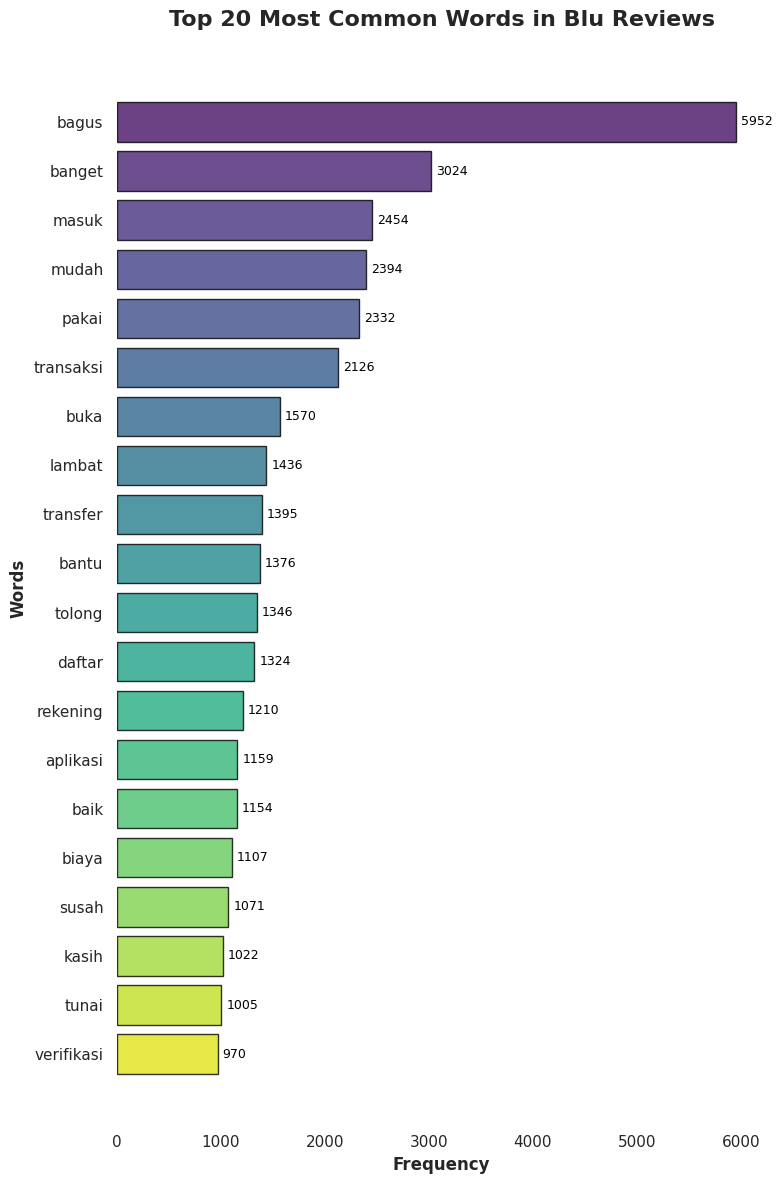

In [ ]:
top_n = 20
top_words = word_freq.head(top_n)

sns.set_theme(style="white")
plt.figure(figsize=(8, 12))

# Create a horizontal bar chart
colors = sns.color_palette("viridis", n_colors=top_n)
bars = plt.barh(top_words['word'], top_words['frequency'], color=colors, edgecolor='black', alpha=0.8)
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Most Common Words in Blu Reviews', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency', fontsize=12, fontweight='bold')
plt.ylabel('Words', fontsize=12, fontweight='bold')
sns.despine(left=True, bottom=True)

# Add data labels to each bar
for i, v in enumerate(top_words['frequency']):
    plt.text(v + 50, i, str(int(v)), color='black', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# **(6) Bigram Analysis**
Specifically extract and analyze the most common two-word phrases (bigrams) to identify recurring themes in the reviews.

This section specifically focuses on identifying and visualizing the most common two-word phrases (bigrams) from the review data. It uses `CountVectorizer` with `ngram_range=(2,2)` to extract bigrams and `numpy.sum` to calculate their frequencies, then plots the top 20.

In [ ]:
vectorizer_bigram = CountVectorizer(
    ngram_range=(2,2),
    min_df=5,
    max_features=50
)

X_bigram = vectorizer_bigram.fit_transform(df_bluRev['final_content'].fillna(''))

bigram_counts = np.sum(X_bigram.toarray(), axis=0)

df_bigram = pd.DataFrame({
    'bigram': vectorizer_bigram.get_feature_names_out(),
    'frequency': bigram_counts
}).sort_values(by='frequency', ascending=False)

df_bigram.head()

,bigram,frequency
40,tarik tunai,573
41,terima kasih,556
15,buka rekening,495
13,biaya admin,465
5,bagus banget,452


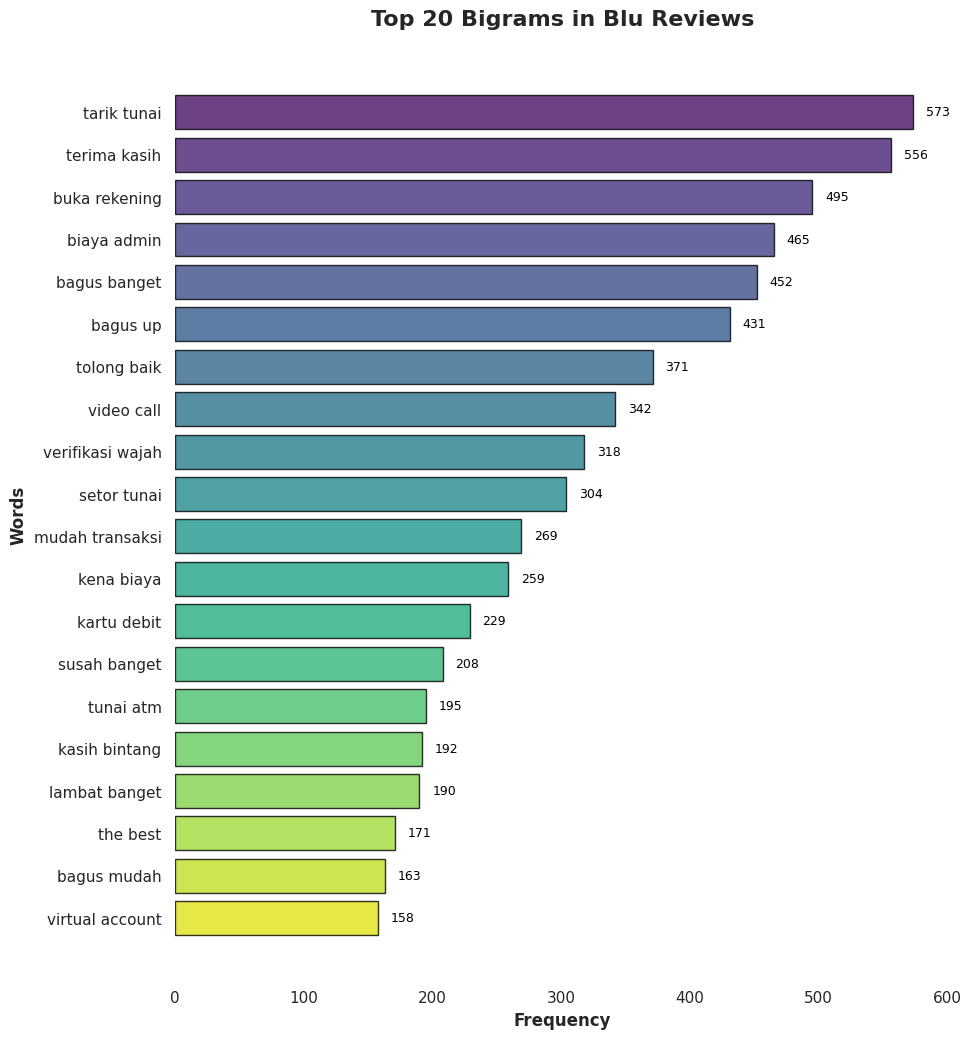

In [ ]:
top_n = 20
top_words = df_bigram.head(top_n)

sns.set_theme(style="white")
plt.figure(figsize=(10, 12))

# Create a horizontal bar chart
colors = sns.color_palette("viridis", n_colors=top_n)
# Use top_words for plotting the bars
bars = plt.barh(top_words['bigram'], top_words['frequency'], color=colors, edgecolor='black', alpha=0.8)
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} Bigrams in Blu Reviews', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Frequency', fontsize=12, fontweight='bold')
plt.ylabel('Words', fontsize=12, fontweight='bold')
sns.despine(left=True, bottom=True)

# Add data labels to each bar, using top_words for iteration
for i, v in enumerate(top_words['frequency']):
    plt.text(v + 10, i, str(int(v)), color='black', va='center', fontsize=9)

plt.show()

# **(7) Regex Analysis: Insights Positive & Negative Reviews**
Building upon the Bag of Words results, this section employs regular expressions (`re.compile`) to categorize reviews into 'Positive Insight' or 'Negative Insight' groups using predefined patterns. A custom `categorize_sentiment` function applies these patterns, and the results are visualized to compare insights across existing sentiment labels.

In [ ]:
# Define positive and negative regex patterns
positive_patterns = [
    r'\b(bagus|mantap|keren|puas|suka|lancar|cepat|mudah|nyaman|aman|best)\b',
    r'\b(recommended|rekomen|bintang\s*5|lima\s*bintang)\b',
    r'\b(terima\s*kasih|terimakasih|makasih)\b',
    r'\b(membantu|berguna|bermanfaat|praktis|simpel)\b',
]

negative_patterns = [
    r'\b(error|gagal|crash|bug|lemot|lambat|lama|hang|susah)\b',
    r'\b(kecewa|buruk|jelek|parah|busuk|sampah|benci)\b',
    r'\b(tidak\s*bisa|gak\s*bisa|gabisa|ga\s*bisa|tdk\s*bisa)\b',
    r'\b(hilang|kehilangan|potong|potongan)\s*(saldo|uang|dana)\b',
    r'\b(refund|pengembalian|kembalikan)\b',
    r'\b(uninstall|hapus)\b',
]

# Compile positive and negative regex patterns for efficient matching
pos_regex = re.compile('|'.join(positive_patterns), re.IGNORECASE)
neg_regex = re.compile('|'.join(negative_patterns), re.IGNORECASE)

print(f'Positive patterns: {len(positive_patterns)} grup')
print(f'Negative patterns: {len(negative_patterns)} grup')

# Function to categorize review sentiment based on regex patterns
def categorize_sentiment(text):
    text = str(text).lower()
    is_positive = bool(pos_regex.search(text))
    is_negative = bool(neg_regex.search(text))

    # Assign categories based on matched patterns
    if is_positive and is_negative:
        return ['Positive Insight', 'Negative Insight']
    elif is_positive:
        return ['Positive Insight']
    elif is_negative:
        return ['Negative Insight']
    else:
        return ['Neutral/Other']

# Apply the categorization function to the 'content' column and explode the results
df_bluRev['categories'] = df_bluRev['content'].apply(categorize_sentiment)
df_exploded = df_bluRev.explode('categories')

# Group and count the categories by existing sentiment labels
sentiment_category_counts = (
    df_exploded
    .groupby(['sentiment_label', 'categories'])
    .size()
    .unstack(fill_value=0)
)

display(sentiment_category_counts)

Positive patterns: 4 grup
Negative patterns: 6 grup


categories,Negative Insight,Neutral/Other,Positive Insight
sentiment_label,,,
negative,4045,2957,962
neutral,779,778,350
positive,1257,6538,8535


In [ ]:
def format_match_output(df_counts, label, category):
    # Calculate total count for a given category
    total = df_counts[category].sum()
    # Get matched count for a specific sentiment label and category
    matched = df_counts.loc[label, category] if label in df_counts.index else 0
    # Calculate percentage of matched reviews within the total category
    percentage = (matched / total * 100) if total > 0 else 0

    return matched, total, percentage

# Get formatted output for negative insights
neg_match, neg_total, neg_pct = format_match_output(
    sentiment_category_counts,
    label='negative',
    category='Negative Insight'
)

# Get formatted output for positive insights
pos_match, pos_total, pos_pct = format_match_output(
    sentiment_category_counts,
    label='positive',
    category='Positive Insight'
)

print(
    f"Negative Insight → Sentimen Negatif: "
    f"{neg_match} dari {neg_total} ({neg_pct:.2f}%)"
)

print(
    f"Positive Insight → Sentimen Positif: "
    f"{pos_match} dari {pos_total} ({pos_pct:.2f}%)"
)

Negative Insight → Sentimen Negatif: 4045 dari 6081 (66.52%)
Positive Insight → Sentimen Positif: 8535 dari 9847 (86.68%)


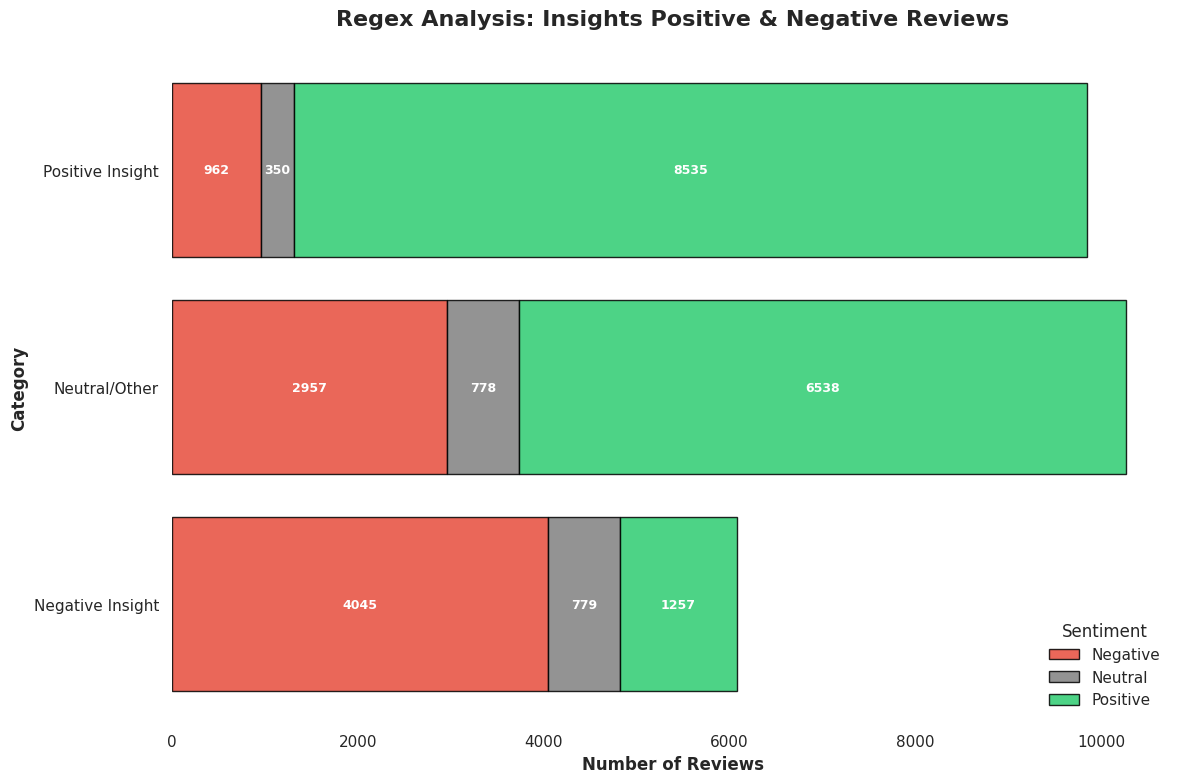

In [ ]:
# Prepare data for plotting by transposing and sorting
plot_data = (
    sentiment_category_counts
    .T
    .sort_values(by='positive', ascending=True)
)

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c', '#808080', '#2ecc71']

left = [0] * len(plot_data)

# Iterate through each sentiment column and create stacked bar segments
for i, col in enumerate(plot_data.columns):
    values = plot_data[col].values

    ax.barh(
        plot_data.index,
        values,
        left=left,
        color=colors[i],
        edgecolor='black',
        alpha=0.85,
        label=col.capitalize()
    )

    # Add data labels to each bar segment
    for j, val in enumerate(values):
        if val > 0:
            ax.text(
                left[j] + val / 2,
                j,
                f"{int(val)}",
                ha='center',
                va='center',
                fontsize=9,
                fontweight='bold',
                color='white'
            )

    left = [l + v for l, v in zip(left, values)]

ax.set_title(
    'Regex Analysis: Insights Positive & Negative Reviews',
    fontsize=16,
    fontweight='bold',
    pad=20
)
ax.set_xlabel('Number of Reviews', fontsize=12, fontweight='bold')
ax.set_ylabel('Category', fontsize=12, fontweight='bold')
ax.legend(title='Sentiment', loc='lower right', frameon=False)
sns.despine(left=True, bottom=True)

plt.tight_layout()
plt.show()